|<img style="float:left;" src="images/usherb_transp.gif">|Pierre Proulx, ing, professeur|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|

# Chapitre 9

## Sections 9.2, 9.3 et 9.4: calcul de la conductivité des gaz, des liquides et des mélanges en fonction de la température, de la pression et de la composition.

Thermo est un package très utile, voyez:

In [1]:
import thermo as th
eau=th.Chemical('water')  # les propriétés par défault sont à 1 atm et 25 degrés C
print('{:10.4e} {:10.4e} {:10.4e} {:10.4e} {:10.4e}'.\
format(eau.kl, eau.mul, eau.mug, eau.rhol, eau.rhog))   
eau.calculate(T=350,P=101325)
print('{:10.4e} {:10.4e} {:10.4e} {:10.4e} {:10.4e}'.\
      format(eau.kl, eau.mul, eau.mug, eau.rhol, eau.rhog))   

6.0652e-01 8.9002e-04 9.6919e-06 9.9705e+02 7.3636e-01
6.6487e-01 3.6847e-04 1.1422e-05 9.7373e+02 6.2727e-01


In [2]:
eau.calculate(T=273.15+80,P=101325*4)  # tout objet créé par Chemical a la méthode calculate... 
eau.kl, eau.kg, eau.mul, eau.mug, eau.rhol, eau.rhog 

(0.6671581720245319,
 None,
 0.00035413237514000365,
 1.1530601332012321e-05,
 971.927317906761,
 2.486704753643284)

In [3]:
import thermo as th
# on utilise thermo pour vérifier quelques valeurs données au tableau 9.1-2
# syntaxe     
#   thermo.Chemical.('substance',T=temperature,P=pression).Prg   # nombre de Prandtl gas
#   thermo.Chemical.('substance',T=temperature,P=pression).Prl   # nombre de Prandtl liquide
#   thermo.Chemical.('substance',T=temperature,P=pression).kg   # conductivité thermique gaz
#   thermo.Chemical.('substance',T=temperature,P=pression).kl   # conductivité thermique gaz
#   th.Mixture([noms des gaz],zs=[fractions],T=temperature,P=pression).kg # conductivité du mélange
for gaz in ['H2','O2','CH4','CO']:
    for temp in [300,400,500]:
        g=th.Chemical(gaz)
        g.calculate(T=temp,P=101325)    # 101325 pascals
        print('Conductivité pour {:4s}à{:4.0f}K, {:6.4f} W/m-K, et Pr= {:4.3f}'.format(gaz,temp,g.kg,g.Prg))

Conductivité pour H2  à 300K, 0.1867 W/m-K, et Pr= 0.685
Conductivité pour H2  à 400K, 0.2311 W/m-K, et Pr= 0.683
Conductivité pour H2  à 500K, 0.2710 W/m-K, et Pr= 0.682
Conductivité pour O2  à 300K, 0.0265 W/m-K, et Pr= 0.716
Conductivité pour O2  à 400K, 0.0340 W/m-K, et Pr= 0.714
Conductivité pour O2  à 500K, 0.0410 W/m-K, et Pr= 0.722
Conductivité pour CH4 à 300K, 0.0344 W/m-K, et Pr= 0.722
Conductivité pour CH4 à 400K, 0.0500 W/m-K, et Pr= 0.718
Conductivité pour CH4 à 500K, 0.0685 W/m-K, et Pr= 0.715
Conductivité pour CO  à 300K, 0.0269 W/m-K, et Pr= 0.691
Conductivité pour CO  à 400K, 0.0333 W/m-K, et Pr= 0.697
Conductivité pour CO  à 500K, 0.0395 W/m-K, et Pr= 0.699


In [4]:
#
# liquides tableau 9.1-3
#
for liquide in ['pentene','CCl4','diethylether','ethanol','glycerol','water']:
    for temp in [300]:
        l=th.Chemical(liquide)
        l.calculate(T=temp)
        print('Conductivité pour {:12s} à{:4.0f} K, {:7.4f} W/m-K'.format(liquide,temp,l.kl,))
        print('   Viscosité pour {:12s} à{:4.0f} K, {:7.4f} Pa-s'.format(liquide,temp,l.mul,))
        print('     Prandtl pour {:12s} à{:4.0f} K, {:7.4f} '.format(liquide,temp,l.Prl,))

Conductivité pour pentene      à 300 K,  0.1095 W/m-K
   Viscosité pour pentene      à 300 K,  0.0002 Pa-s
     Prandtl pour pentene      à 300 K,  3.8608 
Conductivité pour CCl4         à 300 K,  0.0979 W/m-K
   Viscosité pour CCl4         à 300 K,  0.0009 Pa-s
     Prandtl pour CCl4         à 300 K,  4.0968 
Conductivité pour diethylether à 300 K,  0.1195 W/m-K
   Viscosité pour diethylether à 300 K,  0.0002 Pa-s
     Prandtl pour diethylether à 300 K,  4.3166 
Conductivité pour ethanol      à 300 K,  0.1631 W/m-K
   Viscosité pour ethanol      à 300 K,  0.0010 Pa-s
     Prandtl pour ethanol      à 300 K, 15.6812 
Conductivité pour glycerol     à 300 K,  0.2821 W/m-K
   Viscosité pour glycerol     à 300 K,  0.8718 Pa-s
     Prandtl pour glycerol     à 300 K, 7359.8077 
Conductivité pour water        à 300 K,  0.6095 W/m-K
   Viscosité pour water        à 300 K,  0.0009 Pa-s
     Prandtl pour water        à 300 K,  5.8559 


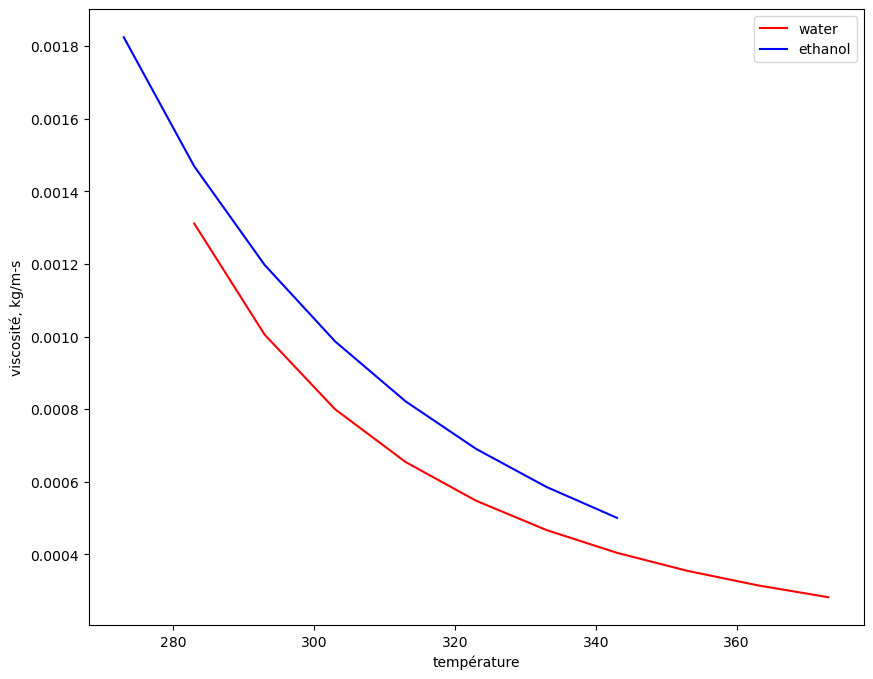

In [5]:
#
# Calcul de la viscosité de liquides en fonction de T
#
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
temp=np.linspace(273,373,11)
visw=temp.copy()
vise=temp.copy()
i=0
plt.rcParams['figure.figsize'] = 10, 8
eau=th.Chemical('water')
booze=th.Chemical('ethanol')
for t in temp:
    eau.calculate(T=t)# attention, si je spécifie pas la pression, c'est la dernière valeur
    booze.calculate(T=t)
    visw[i]=eau.mul
    vise[i]=booze.mul
    i=i+1
p=plt.plot(temp,visw,'r',temp,vise,'b')
plt.xlabel('température')
plt.legend(('water','ethanol'))
plt.ylabel('viscosité, kg/m-s')
plt.show()

In [6]:
# Exemple 9.3-3
melange=th.Mixture(['CO2','O2','N2'],zs=[0.133,0.039,0.828],T=273+20,P=1*101325) # fraction molaire zs, massique ws
kmix=melange.kg   
print("Conductivité du mélange {:6.4f} W/m-K ou {:7.7f} cal/cm-s-K ".format(kmix,kmix*0.00239))

Conductivité du mélange 0.0241 W/m-K ou 0.0000576 cal/cm-s-K 


In [7]:
#
# Calcul de la viscosité du mélange eau-éthanol, attention au comportement non-linéaire
#
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from ipywidgets import *
def f(Tf):
    w=np.linspace(0.001,0.999,11)
    visew=w.copy()
    vispw=w.copy()
    i=0
    plt.rcParams['figure.figsize'] = 8,6
    for frac in w:
        vispw[i]=th.Mixture(['ethanol','water'],ws=[w[i],1-w[i]],T=273+Tf).mul
        i=i+1
    p=plt.plot(w,vispw)
    plt.ylim([0,0.01])
    plt.grid()
    plt.xlabel('concentration ethanol (fraction massique)')
    plt.ylabel('viscosité, kg/m-s')
    plt.show();
kmelange=interactive(f,Tf=(-10,50,1));
display(kmelange)

interactive(children=(IntSlider(value=20, description='Tf', max=50, min=-10), Output()), _dom_classes=('widget…

<img src='images/ethanol-eau.gif'>